## Preprocessing

### 0. Index
1. Train/Test split
2. Replace 0 to NaN
3. Imputation
4. Feature Engineering
5. Feature Selection
    5.a. Correlation analysis
    5.b. Multicollinearity check 
    5.c. Variance inflation factor (VIF) 
    5.d. Ablation tests
6. Select features to train


During the exploratory data analysis phase, a significant number of duplicate rows were identified and removed, reducing the dataset from 1025 to 302 observations.

The dataset does not require imputation because no missing values or invalid zero values were detected. The target variable is balanced, so a stratified train-test split will be used to preserve class proportions. Outliers are retained at this stage because they may represent clinically meaningful patient variation rather than data errors.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# This adds the parent directory (project root) to the Python path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

In [3]:
from src.utils.config import CFG, PROJECT_ROOT

In [4]:
#Load data
df = pd.read_csv(PROJECT_ROOT / CFG["paths"]["raw_data"])

In [5]:
df_clean = df.drop_duplicates()

In [6]:
df_clean = df_clean.reset_index(drop=True)

In [7]:
print(df_clean.index[:5].tolist())
print(df_clean.index[-5:].tolist())

[0, 1, 2, 3, 4]
[297, 298, 299, 300, 301]


### 1. Train/Test split
goal: 
302 patients:
    - train: 181 (60%) - used for the model to learn patterns from the data.
    - val: 61(20%) - used fro hyperparameter tuning and model selection.
    - test: 60(20%) - used for final model evaluation, one time use

In [8]:
from src.data.split_data import split_data 

X_train, X_val, X_test, Y_train, Y_val, Y_test = split_data(df_clean)

The class proportions remain consistent across the training and testing sets, confirming that stratification preserved the target distribution.

figure saves in /Users/miluskapajuelo/Documents/Heart-Disease-Prediction-using-Machine-Learning-End-to-End-ML-Pipeline-/figures/split_class_balance.png


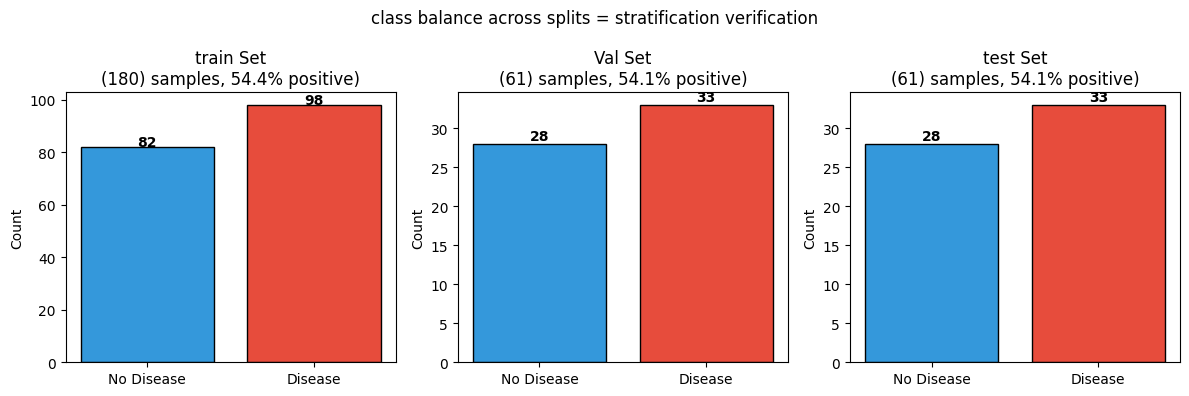

In [9]:
from src.utils.helpers import save_figure
# verify the balance of classes preservation stratification

splits_info ={
    "train":Y_train,
    "Val":Y_val,
    "test": Y_test
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, y) in zip(axes, splits_info.items()):
    counts = y.value_counts().sort_index()
    ax.bar(
        ['No Disease', 'Disease'],
        counts.values,
        color=["#3498db", '#e74c3c'],
        edgecolor= 'black'
    )
    ax.set_title(f'{name} Set\n({len(y)}) samples, {y.mean():.1%} positive)')
    ax.set_ylabel('Count')

    for i, v in enumerate(counts.values):
        ax.text(i, v+0.5, str(v), ha="center", fontweight="bold")

plt.suptitle(
    'class balance across splits = stratification verification',
    fontsize=12
)
plt.tight_layout()
save_figure(
    fig,
    PROJECT_ROOT / CFG['paths']['figures_dir'] / 'split_class_balance.png'
)


### 2. Replace 0 to NaN

goal: I have identified attributes that should not contain zero, and if they contain zeros, they will be replace by NaN before the imputer process

In [10]:
zero_cols = CFG["preprocessing"]["zero_as_nan_col"]
zero_cols

['chol', 'trestbps', 'thalach']

In [11]:
from src.data.preprocess import replace_zero_with_nan, fit_imputer, add_engineered_features


In [12]:
# replace zero in all 3 splits
x_train_proc = replace_zero_with_nan(X_train, zero_cols)
x_val_proc = replace_zero_with_nan(X_val, zero_cols)
x_test_proc = replace_zero_with_nan(X_test, zero_cols)

### 3. Imputation - fit on train only

goal: fill missing values using the median learned from the training set only

These same medians are applied to `X_val` and `X_test` without refitting. This prevents data leakage — test information never influences the imputation values used during training.

The fitted imputer is saved as `models/preprocessor.pkl` for production use. When a new patient arrives, their data goes through the exact same
transformation with the exact same medians.

In [13]:
X_train_imp, X_test_imp, X_val_imp, imputer = fit_imputer(x_train_proc, x_val_proc, x_test_proc)

 medians learned from training set 

 age:  55.00
 sex:  1.00
 cp:  1.00
 trestbps:  130.00
 chol:  241.50
 fbs:  0.00
 restecg:  0.50
 thalach:  154.50
 exang:  0.00
 oldpeak:  0.60
 slope:  1.00
 ca:  0.00
 thal:  2.00


In [14]:
X_train_imp.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

### 4. Feature engineering

goal: encode clinical domain knowledge into 4 composite features that capture relationship between raw variables. I worked with dr. Morgan Carson-Marino(PharmD, MS)

Four new features are created from the imputed data:

| Feature | Formula | Clinical Meaning |
|---|---|---|
| `cardiac_capacity` | `thalach / age` | Max heart rate efficiency relative to age |
| `isquemia_score` | `oldpeak + exang + (ca / 3)` | Composite ischemia risk |
| `est_stroke_volume` | `(trestbps / thalach) × (age / 50)` | Proxy for cardiac work efficiency |
| `troponin_index` | `(oldpeak × 1.5) + (exang × 2) + (ca × 1.2)` | Weighted ischemia marker |


After engineering, 8 features are selected based on clinical
relevance and correlation with the target.

In [15]:
X_train_fe, X_val_fe, X_test_fe = add_engineered_features(
    X_train_imp, X_val_imp, X_test_imp
)

In [16]:
X_train_fe.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'cardiac_capacity',
 'isquemia_score',
 'est_stroke_volume',
 'troponin_index']

### 5. Feature selection

#### 5.a. Correlation analysis
goal: before selecting which featuures to pass to the models, we meadure the linear correlation of all 17 features (13 raws, and 4 engineered)

features with correlation near zero (|r|<0.10) are candidates to removal


In [17]:
from src.data.preprocess import corr_features_with_target

figure saves in /Users/miluskapajuelo/Documents/Heart-Disease-Prediction-using-Machine-Learning-End-to-End-ML-Pipeline-/figures/correlation_all_17.png


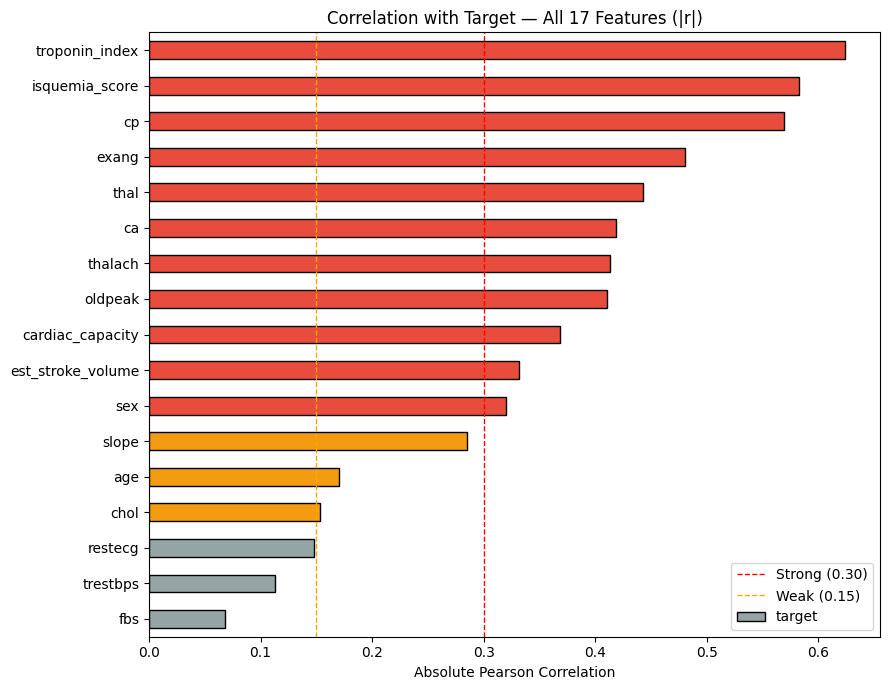

In [18]:
all_features = X_train_fe.copy()
all_features["target"] = Y_train.values

corr_with_target = corr_features_with_target(all_features, "target")

fig, ax = plt.subplots(figsize=(9,7))
colors = ['#e74c3c' if v > 0.30 else '#f39c12' if v > 0.15 else '#95a5a6'
          for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(0.30, color='red',    linestyle='--', linewidth=1, label='Strong (0.30)')
ax.axvline(0.15, color='orange', linestyle='--', linewidth=1, label='Weak (0.15)')
ax.set_title('Correlation with Target — All 17 Features (|r|)', fontsize=12)
ax.set_xlabel('Absolute Pearson Correlation')
ax.legend()
plt.tight_layout()
save_figure(fig, PROJECT_ROOT / CFG['paths']['figures_dir'] / 'correlation_all_17.png')
plt.show()

In [19]:
print("\nCorrelation with target (sorted by absolute value):")
print(corr_with_target.round(4).to_string())
print("\nWeak features (|r| < 0.10):  candidates for removal")
print(corr_with_target[corr_with_target < 0.10].index.tolist())


Correlation with target (sorted by absolute value):
fbs                  0.0684
trestbps             0.1128
restecg              0.1478
chol                 0.1536
age                  0.1703
slope                0.2851
sex                  0.3204
est_stroke_volume    0.3320
cardiac_capacity     0.3686
oldpeak              0.4108
thalach              0.4136
ca                   0.4182
thal                 0.4426
exang                0.4804
cp                   0.5690
isquemia_score       0.5825
troponin_index       0.6240

Weak features (|r| < 0.10):  candidates for removal
['fbs']



#### 5.b. Multicollinearity check 
goal: two features that are hightly correlated with each other carry redundant information. Having both in the model is not efficient for the capacity and destabilizes Logistic Regression weights.

Feature pairs with |r| > 0.70 are candidates for consolidation

In [20]:
import seaborn as sns
from src.data.preprocess import multicollinearity_between_functions

figure saves in /Users/miluskapajuelo/Documents/Heart-Disease-Prediction-using-Machine-Learning-End-to-End-ML-Pipeline-/figures/feature_correlation_heatmap.png


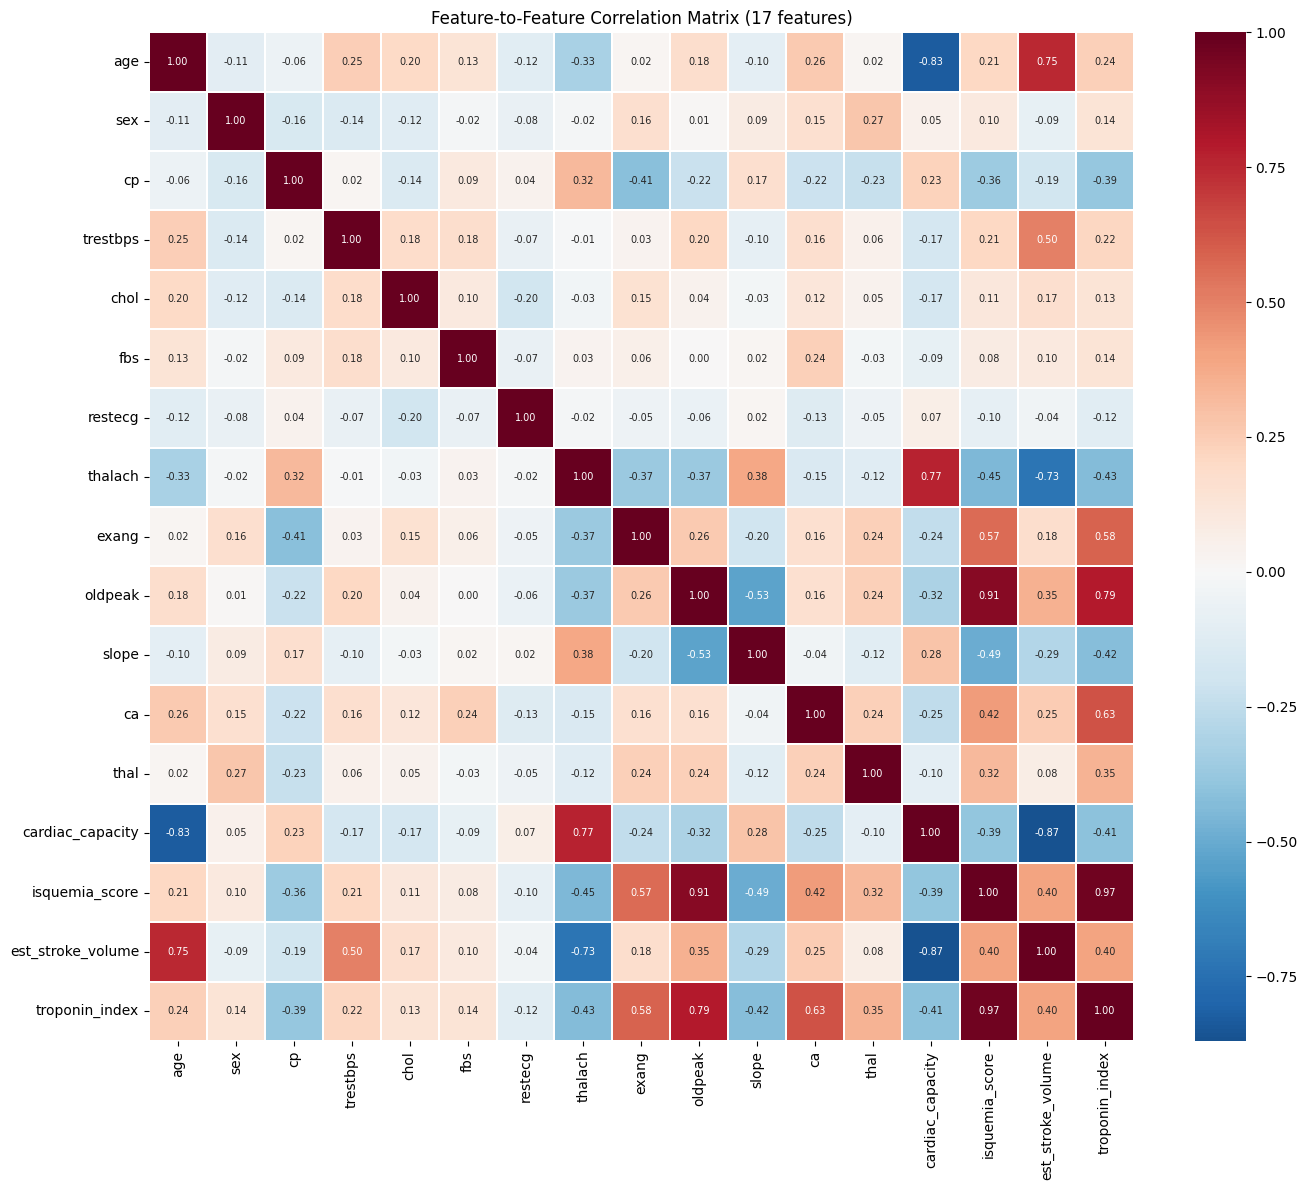

Highly correlated feature pairs (|r| > 0.70):
  age                    ↔  cardiac_capacity        r = 0.830
Grade of correlation with target:
  fbs                        0.068   weak, candidate for removal
  trestbps                   0.113   weak, candidate for removal
  restecg                    0.148   weak, candidate for removal
  chol                       0.154   moderate
  age                        0.170   moderate
  slope                      0.285   moderate
  sex                        0.320   strong
  est_stroke_volume          0.332   strong
  cardiac_capacity           0.369   strong
  oldpeak                    0.411   strong
  thalach                    0.414   strong
  ca                         0.418   strong
  thal                       0.443   strong
  exang                      0.480   strong
  cp                         0.569   strong
  isquemia_score             0.582   strong
  troponin_index             0.624   strong


In [21]:
# Heatmap of all 17 features with each other
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = X_train_fe.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    linewidths=0.3,
    annot_kws={"size": 7}
)
ax.set_title('Feature-to-Feature Correlation Matrix (17 features)', fontsize=12)
plt.tight_layout()
save_figure(fig, PROJECT_ROOT / CFG['paths']['figures_dir'] / 'feature_correlation_heatmap.png')
plt.show()

# Print pairs with high mutual correlation
print("Highly correlated feature pairs (|r| > 0.70):")
found = False
col1, col2, r = multicollinearity_between_functions(all_features)
print(f"  {col1:<22} ↔  {col2:<22}  r = {r:.3f}")
found = True
print("Grade of correlation with target:")
for feature, r in corr_with_target.items():
    if abs(r) >= 0.30:
        signal = "strong"
    elif abs(r) >= 0.15:
        signal = "moderate"
    else:
        signal = "weak, candidate for removal"  
    print(f"  {feature:<23} {r:>8.3f}   {signal}")
if not found:
    print("  None found above 0.70")

Based on the results:
- isquemia_score         ↔  troponin_index:  are essentially the same feature with different weights, this is not multicollinearity, it is multiplication.
decision: remove troponin_index
- cardiac_capacity       ↔  est_stroke_volume: they both shared 2 same variables, but est_stroke_volume has trestbps - blood preasure.
decision: remove cardiac_capacity
- oldpeak                ↔  isquemia_score : in isquemia_score oldpeak is dominant; therefore, oldpeak is already absorbed. 
decision: remove oldpeak
- thalach                ↔  est_stroke_volume  : thalach is already absorbed in est_stroke_volume. 
decision: remove thalach
- age                    ↔  est_stroke_volume  : age is already absorbed in est_stroke_volume. 
decision: remove age

In [22]:
TO_REMOVE = [
    "troponin_index",
    "cardiac_capacity",
    "oldpeak",
    "thalach",
    "age",
    "fbs",
    "trestbps",
    "restecg"
]

#### 5.c. Variance inflation factor (VIF) 
goal: VIF measures how much a feature's variance is inflated by its correlation with other features


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [24]:
candidates = corr_with_target[corr_with_target >= 0.10].index.tolist()
x_vif = X_train_fe[candidates].copy()

vif_df = pd.DataFrame({
    'feature': x_vif.columns,
    'VIF': [
        variance_inflation_factor(x_vif.values, i)
        for i in range(x_vif.shape[1])
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF):")
print(vif_df.to_string(index=False))

print("\nSevere multicollinearity (VIF > 10):")
severe = vif_df[vif_df['VIF'] > 10]
if len(severe) > 0:
    print(severe.to_string(index=False))
else:
    print("  None")

Variance Inflation Factor (VIF):
          feature         VIF
          oldpeak         inf
               ca         inf
            exang         inf
   isquemia_score         inf
   troponin_index         inf
          thalach 1004.300578
              age  565.856731
         trestbps  374.644038
est_stroke_volume  306.511959
 cardiac_capacity  157.550203
             chol   27.349334
             thal   17.854264
            slope   11.116230
              sex    3.742615
               cp    2.506258
          restecg    2.113363

Severe multicollinearity (VIF > 10):
          feature         VIF
          oldpeak         inf
               ca         inf
            exang         inf
   isquemia_score         inf
   troponin_index         inf
          thalach 1004.300578
              age  565.856731
         trestbps  374.644038
est_stroke_volume  306.511959
 cardiac_capacity  157.550203
             chol   27.349334
             thal   17.854264
            slope   11.116230

/Users/miluskapajuelo/Documents/Heart-Disease-Prediction-using-Machine-Learning-End-to-End-ML-Pipeline-/.venv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


#### 5.d. Ablation tests
goal: validate each feature with conflicting signals

- ca:
    - corr with target 0.418 STRONG
    - VIF is inf FLAG DEPENDENCY
    - it is in a engineered feature. (isquemia_score), but with a 0.42 corr score
    Conflict: strong target signal but potentially already captured

- exang:
    - corr with target 0.480 STRONG
    - VIF is inf FLAG DEPENDENCY
    - it is in a engineered feature. (isquemia_score), but with a 0.57 corr score
    Conflict: strong target signal but potentially already captured

- slope:
    - corr with target 0.285 MODERATE
    - corr with isquemia_score  0.49
    - it is not in any engineered feature
    Conflict: moderate signal but overlaps partially with isquemia_score

- restecg:
    - corr with target 0.148 WEAK
    - VIF is 2.1 LOW, it is an independent feature
    Conflict: weak signal but no redundancy at all

- chol:
    - corr with target 0.154 WEAK
    - VIF is 27.34 LOW, it is an independent feature
    Conflict: weak signal but no redundancy at all

In [25]:
TO_ABLATION_TEST = [
    'ca', 
    'slope',
    'exang',
    'restecg',
    'chol'
]

In [26]:
#  X_train_fe contains 17 features (raws + engineered features)
POTENTIAL_NO_KEEP = TO_REMOVE + TO_ABLATION_TEST
TO_KEEP = [feature for feature in X_train_fe.copy().columns.tolist() if feature not in POTENTIAL_NO_KEEP]
TO_KEEP

['sex', 'cp', 'thal', 'isquemia_score', 'est_stroke_volume']

In [27]:
configs = {
    'TO_KEEP (5)':                  TO_KEEP,
    'TO_KEEP + slope':              TO_KEEP + ['slope'],
    'TO_KEEP + ca':                 TO_KEEP + ['ca'],
    'TO_KEEP + exang':              TO_KEEP + ['exang'],
    'TO_KEEP + chol':               TO_KEEP + ['chol'],
    'TO_KEEP + restecg':            TO_KEEP + ['restecg']

}

In [28]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

In [29]:
def quick_auc(cols):
    """
    Train a fixed XGBoost and return val ROC-AUC.
    """
    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_fe[cols], Y_train)
    return roc_auc_score(Y_val, model.predict_proba(X_val_fe[cols])[:, 1])

In [30]:
baseline_auc = None

for name, cols in configs.items():
    auc = quick_auc(cols)

    if baseline_auc is None:
        baseline_auc = auc
        diff_str = "— (baseline)"
    else:
        diff = auc - baseline_auc
        symbol = "↑" if diff > 0 else "↓"
        diff_str = f"{symbol} {abs(diff):.4f}"

    print(f"  {name:<33} {auc:.4f}   {diff_str:>12}")

  TO_KEEP (5)                       0.8187   — (baseline)
  TO_KEEP + slope                   0.8236       ↑ 0.0049
  TO_KEEP + ca                      0.8128       ↓ 0.0060
  TO_KEEP + exang                   0.8198       ↑ 0.0011
  TO_KEEP + chol                    0.8084       ↓ 0.0103
  TO_KEEP + restecg                 0.8106       ↓ 0.0081


Based on this first individual result: 
- ca, chol and restecg hurt performance

In [31]:
configs_fase2 = {
    'TO_KEEP (5)':             TO_KEEP,
    'TO_KEEP + slope':         TO_KEEP + ['slope'],
    'TO_KEEP + slope + exang': TO_KEEP + ['slope', 'exang'],
}

In [32]:
baseline_auc = None

for name, cols in configs_fase2.items():
    auc = quick_auc(cols)

    if baseline_auc is None:
        baseline_auc = auc
        diff_str = "— (baseline)"
    else:
        diff = auc - baseline_auc
        symbol = "↑" if diff > 0 else "↓"
        diff_str = f"{symbol} {abs(diff):.4f}"

    print(f"  {name:<33} {auc:.4f}   {diff_str:>12}")

  TO_KEEP (5)                       0.8187   — (baseline)
  TO_KEEP + slope                   0.8236       ↑ 0.0049
  TO_KEEP + slope + exang           0.8203       ↑ 0.0016


I will keep slope, but exang do not contribute much to the performance, for that reason I will not consider exang for training.

### 6. Select features to train

goal: features ready for model training


In [35]:
# Once I have the selected features I created a customize function with the engineered features
from src.features.buiid_features import build_features

In [36]:
X_train_fe, X_val_fe, X_test_fe = build_features( X_train_imp, X_val_imp, X_test_imp )

  Features before engineering : 13
  Features after engineering  : 15
  Features selected for models: ['sex', 'cp', 'thal', 'isquemia_score', 'est_stroke_volume', 'slope']
  Nulls in X_train_fe: ✔
  Nulls in X_val_fe: ✔
  Nulls in X_test_fe: ✔
